# Week 6 | Feature engineering, scaling and encoding
**Goal:** create a documented numeric representation for descriptive PCA.

We exclude ID, both outcome representations, the ambiguous tenure-in-months field and
audit flags. Six numeric and fifteen categorical fields remain. This is a full-cohort
descriptive fit; a future predictive experiment must split data before fitting preprocessing.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = next((p if (p/'Source_Code'/'attrition_lab.py').exists() else p/'DSV_PROJECT'
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p/'Source_Code'/'attrition_lab.py').exists() or (p/'DSV_PROJECT'/'Source_Code'/'attrition_lab.py').exists()), None)
if ROOT is None: raise FileNotFoundError('Open this notebook inside DSV_PROJECT')
sys.path.insert(0,str(ROOT/'Source_Code'))
from attrition_lab import load_raw, clean_data, rate_table
raw=load_raw(); clean=clean_data(raw)
pd.set_option('display.max_columns',12)

In [2]:
from advanced_analysis import transform_features, NUM_FEATURES, CAT_FEATURES, EXCLUDED
features=transform_features(clean)
display(pd.DataFrame(EXCLUDED.items(),columns=['excluded_field','reason']))
display(features['transformations'])

,excluded_field,reason
0,Employee ID,"Identifier, no analytical distance meaning"
1,Attrition,Outcome excluded from unsupervised fit
2,Left,Derived outcome excluded
3,Company Tenure (In Months),Definition conflicts with Years at Company; un...
4,Distance from Home Missing,"Audit flag, kept outside primary PCA"
5,Company Tenure (In Months) Missing,"Audit flag, kept outside primary PCA"
6,Early Start Flag,"Audit assumption, kept outside primary PCA"
7,Tenure Definition Review,"Audit assumption, kept outside primary PCA"
8,Income IQR Flag,"Audit flag, kept outside primary PCA"


,feature,raw_skew,candidate_yj_skew,applied,lambda,selected_skew
0,Age,-0.001608,-0.001608,Identity,NaN,-0.001608
1,Years at Company,0.789908,0.789908,Identity,NaN,0.789908
2,Monthly Income,5.207805,0.037936,Yeo-Johnson,0.171253,0.037936
3,Number of Promotions,0.992795,0.992795,Identity,NaN,0.992795
4,Distance from Home,0.001634,0.001634,Identity,NaN,0.001634
5,Number of Dependents,0.918378,0.918378,Identity,NaN,0.918378


## Why transform income?
The predeclared exploratory trigger is absolute skewness above 1 for nonconstant numeric
fields. Yeo–Johnson is selected only if it reduces absolute skewness. The other fields keep
their original shapes. The resulting shape is not proof of normality or more truthful data.

MinMax scaling changes range; StandardScaler changes center and scale. Neither by itself
removes skewness. The selected income transformation happens **before** standardization.

Income skew: **5.208 → 0.038**, using Yeo-Johnson.

,feature,center_after_shape_transform,scale_after_shape_transform,standard_mean,standard_std_ddof0,minmax_min,minmax_max
0,Age,38.529746,12.083375,2.109749e-16,1.0,0.0,1.0
1,Years at Company,15.721603,11.223669,-9.041780e-17,1.0,0.0,1.0
2,Monthly Income,20.782564,1.469735,-1.744453e-15,1.0,0.0,1.0
3,Number of Promotions,0.832935,0.995282,1.020538e-17,1.0,0.0,1.0
4,Distance from Home,49.992282,28.151796,2.899474e-17,1.0,0.0,1.0
5,Number of Dependents,1.657494,1.579948,-5.283909e-17,1.0,0.0,1.0


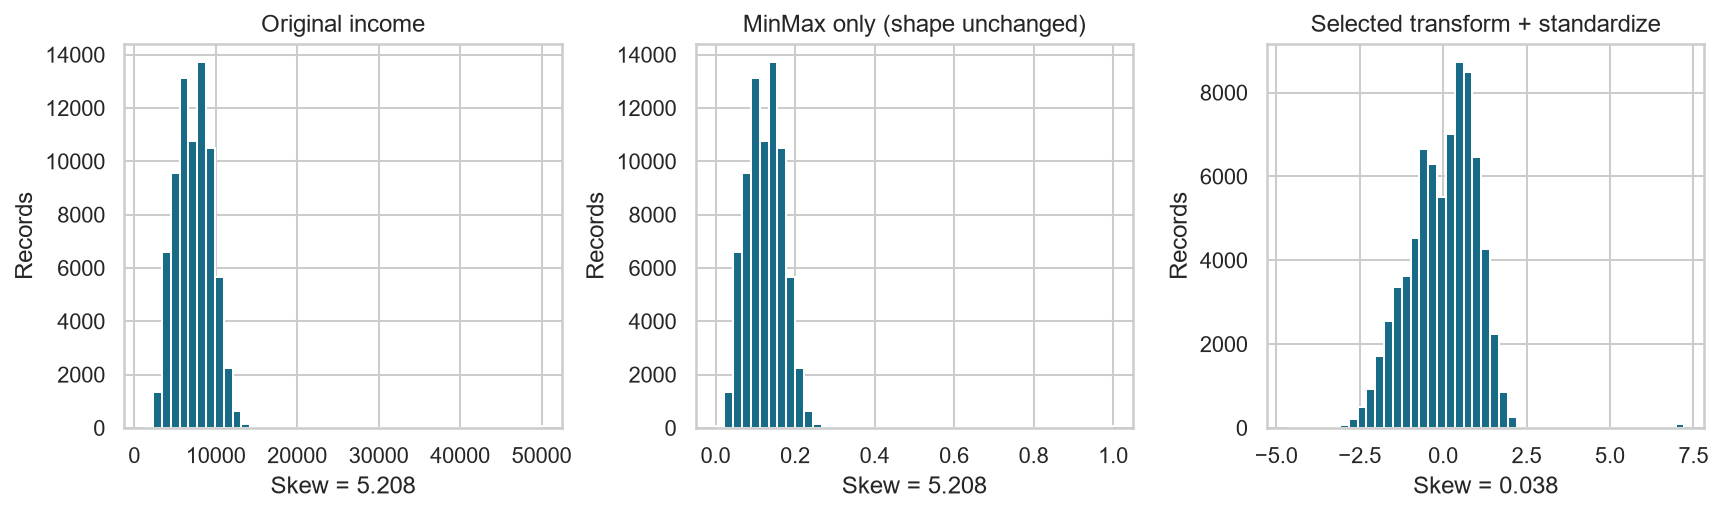

In [3]:
income=features['transformations'].set_index('feature').loc['Monthly Income']
display(Markdown(f"Income skew: **{income.raw_skew:.3f} → {income.selected_skew:.3f}**, using {income.applied}."))
display(features['scaling'])
display(Image(filename=str(ROOT/'Reports'/'Figures'/'06_income_transformations.png')))

## Encoding and weighting
One-hot encoding avoids inventing equal spacing between labels such as Fair and Good.
We drop one category per field to avoid exact dummy redundancy. The dropped category and
all observed categories are recorded. Unknown categories raise an error in this descriptive
fit instead of silently becoming the reference group.

Numeric features have unit variance; dummies remain 0/1. This is a deliberate weighting
choice. Week 7 compares it with standardizing every encoded column.

In [4]:
display(features['encoding'])
print('Encoded matrix:',features['matrix'].shape)
assert not {'Employee ID','Attrition','Left'}.intersection(features['matrix'].columns)
assert np.isfinite(features['matrix']).all().all()
display(features['matrix'].head(3))

,feature,categories,reference_category,output_columns
0,Gender,Female | Male,Female,1
1,Job Role,Education | Finance | Healthcare | Media | Tec...,Education,4
2,Work-Life Balance,Excellent | Fair | Good | Poor,Excellent,3
3,Job Satisfaction,High | Low | Medium | Very High,High,3
4,Performance Rating,Average | Below Average | High | Low,Average,3
5,Overtime,No | Yes,No,1
6,Education Level,Associate Degree | Bachelor's Degree | High Sc...,Associate Degree,4
7,Marital Status,Divorced | Married | Single,Divorced,2
8,Job Level,Entry | Mid | Senior,Entry,2
9,Company Size,Large | Medium | Small,Large,2


Encoded matrix: (74498, 40)


,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,...,Company Reputation_Fair,Company Reputation_Good,Company Reputation_Poor,Employee Recognition_Low,Employee Recognition_Medium,Employee Recognition_Very High
0,-0.623149,0.292097,-0.807958,1.172597,-0.994334,-1.049081,...,0.0,0.0,0.0,0.0,1.0,0.0
1,1.694084,-1.044365,-0.729659,2.177337,-1.029855,0.849715,...,1.0,0.0,0.0,1.0,0.0,0.0
2,-1.202458,-0.509780,0.465148,-0.836883,-1.385073,0.849715,...,0.0,0.0,1.0,1.0,0.0,0.0


**Saved files:** `feature_transformations.csv`, `feature_scaling.csv`,
`feature_encoding.csv`, `feature_exclusions.csv` and the two Week 6 figures in Reports.
Regenerate outputs with `python Source_Code/advanced_analysis.py`.

[Scikit-learn preprocessing documentation](https://scikit-learn.org/stable/modules/preprocessing.html)